In [ ]:
# 1. Install libraries (Colab has most of these, but this ensures they are present)
!pip install -q tensorflow opencv-python scikit-learn matplotlib seaborn numpy pandas

# 2. Import the libraries
import tensorflow as tf
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# 3. Check GPU availability
print("--- System Check ---")
device_name = tf.test.gpu_device_name()

if device_name != '/device:GPU:0':
    print("GPU device not found. (Check Edit -> Notebook settings -> Hardware accelerator)")
else:
    print(f"Found GPU at: {device_name}")

# Additional GPU details
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"Number of GPUs available: {len(gpu_devices)}")
    for gpu in gpu_devices:
        print(f" - {gpu}")

# 4. Display versions for reference
print(f"\n--- Library Versions ---")
print(f"TensorFlow: {tf.__version__}")
print(f"OpenCV:     {cv2.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"Pandas:     {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")

--- System Check ---
Found GPU at: /device:GPU:0
Number of GPUs available: 1
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

--- Library Versions ---
TensorFlow: 2.19.0
OpenCV:     4.13.0
NumPy:      2.0.2
Pandas:     2.2.2
Scikit-learn: 1.6.1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
import zipfile
import os

# 1. Mount Google Drive
# This will prompt you to click a link and authorize access
drive.mount('/content/drive')

# 2. Define Paths
# IMPORTANT: Change 'ColabData/dataset.zip' to your actual folder/filename on Drive
zip_path = '/content/drive/MyDrive/colabdata/dataset.zip'
extract_destination = '/content/dataset_local'

# 3. Extraction Logic
if os.path.exists(zip_path):
    print(f"📦 Found zip at: {zip_path}")
    print("🚀 Extracting to local runtime (this is faster for training)...")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_destination)

    print("✅ Extraction complete!")
else:
    print(f"❌ Error: Could not find '{zip_path}'. Check your Drive folder name.")

# 4. Function to Visualize Folder Structure
def list_files(startpath):
    print(f"\n--- Folder Structure of {startpath} ---")
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f"{indent}📂 {os.path.basename(root)}/")
        subindent = ' ' * 4 * (level + 1)
        # Show only first 5 files per folder to avoid spamming the output
        for f in files[:5]:
            print(f"{subindent}📄 {f}")
        if len(files) > 5:
            print(f"{subindent}... and {len(files)-5} more files.")

list_files(extract_destination)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Found zip at: /content/drive/MyDrive/colabdata/dataset.zip
🚀 Extracting to local runtime (this is faster for training)...
✅ Extraction complete!

--- Folder Structure of /content/dataset_local ---
📂 dataset_local/
    📂 dataset/
        📂 train/
            📂 safe/
                📄 image1260.jpg
                📄 P1020674.JPG
                📄 image528.jpg
                📄 image827.jpg
                📄 image534.jpg
                ... and 1308 more files.
            📂 obstacle/
                📂 vehicle/
                    📄 -BE412F80-6FDD-4522-8C6B-D26DA55927F5-png_jpg.rf.1616bbe08850d0465cdc1ed72b2b7dbb.jpg
                    📄 -192C4A31-07E9-4438-9D0D-63CF545747C8-png_jpg.rf.323c7c0e4a7031747ad5ec9591fbc708.jpg
                    📄 793_jpg.rf.7f59c7a23b277d983b32b66162042263.jpg
                    📄 Xe-tai-20_jpg.rf.48bf529f44b3f642d8ec7816298acd

In [ ]:
!ls -R /content/dataset_local | head -n 20

/content/dataset_local:
dataset

/content/dataset_local/dataset:
test
train
validation

/content/dataset_local/dataset/test:
danger
obstacle
safe

/content/dataset_local/dataset/test/danger:
ABbframe00154.jpg
ABbframe00160.jpg
ABbframe00166.jpg
ABbframe00169.jpg
ABbframe00190.jpg
ABbframe00235.jpg


--- Loading Datasets ---
Found 5245 files belonging to 3 classes.
Found 892 files belonging to 3 classes.
Found 1255 files belonging to 3 classes.

Detected classes: ['danger', 'obstacle', 'safe']

Displaying augmented samples...


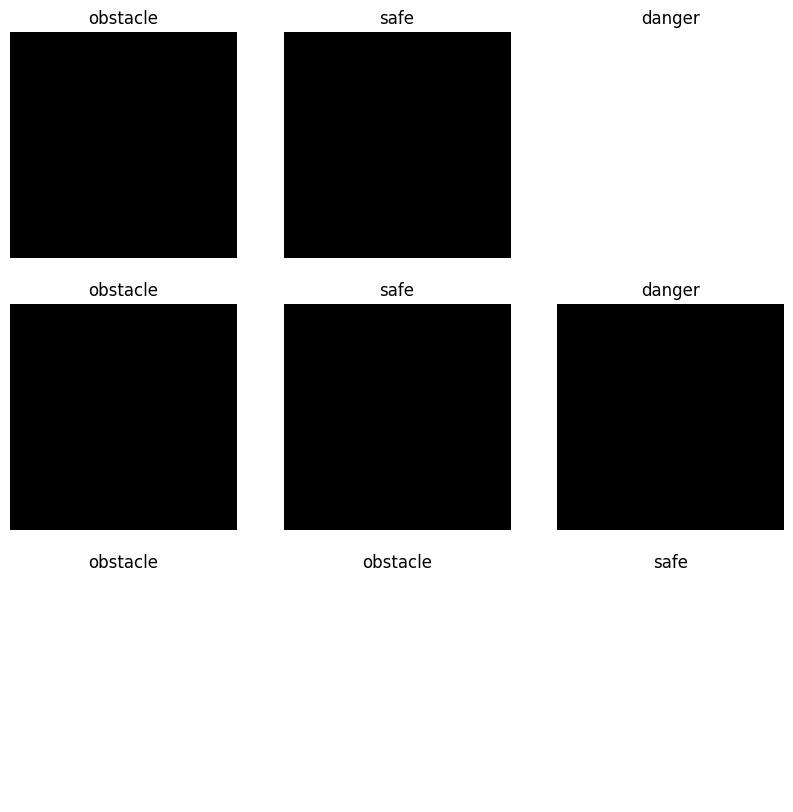

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os

# 1. Corrected Configuration based on your file structure
DATA_DIR = '/content/dataset_local/dataset'  # Updated path
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# 2. Load Datasets
print("--- Loading Datasets ---")
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'train'),
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'validation'),
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'test'),
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
print(f"\nDetected classes: {class_names}")

# 3. Augmentation and Normalization
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.2),
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.2),
    layers.RandomBrightness(0.2),
])

rescaling_layer = layers.Rescaling(1./255)

def prepare(ds, augment=False):
    # Apply rescaling to all images
    ds = ds.map(lambda x, y: (rescaling_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        # Apply augmentation only to training set
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# Apply the pipeline
train_ds = prepare(train_ds, augment=True)
val_ds = prepare(val_ds)
test_ds = prepare(test_ds)

# 4. Show 9 Sample Images
print("\nDisplaying augmented samples...")
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # We use .numpy() because it's a EagerTensor
        plt.imshow(images[i].numpy())

        # Determine the class name from the one-hot label
        label_idx = tf.argmax(labels[i]).numpy()
        plt.title(class_names[label_idx])
        plt.axis("off")

plt.show()

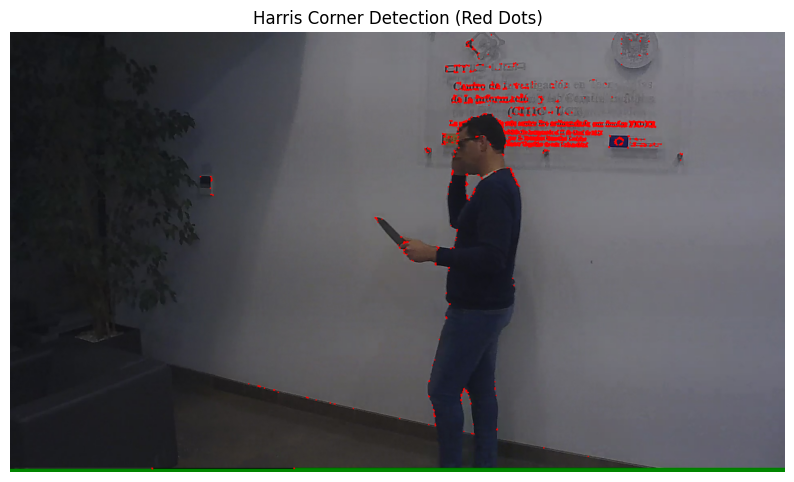

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read an RGB image
# (Updating path to one of your danger folder images found in the previous step)
img_path = '/content/dataset_local/dataset/test/danger/ABbframe00154.jpg'
image = cv2.imread(img_path)

# OpenCV reads in BGR format by default; convert to RGB for correct colors in Matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 2. Convert to Grayscale
# Harris Corner Detection requires a 8-bit or floating-point single-channel image
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Convert grayscale to float32 (required by the cornerHarris function)
gray = np.float32(gray)

# 3. Apply cv2.cornerHarris
# Parameters: (image, block_size, ksize, k)
# block_size: size of the neighborhood considered for corner detection
# ksize: aperture parameter of the Sobel derivative used
# k: Harris detector free parameter in the equation
dst = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

# Dilate the result to mark the corners more clearly (makes them "thicker")
dst = cv2.dilate(dst, None)

# 4. Highlight corners in red
# Threshold for an optimal value; it may vary depending on the image.
# We set the original RGB image to Red [255, 0, 0] where the Harris response is high.
image_rgb[dst > 0.01 * dst.max()] = [255, 0, 0]

# 5. Display result using matplotlib
plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.title('Harris Corner Detection (Red Dots)')
plt.axis('off')
plt.show()

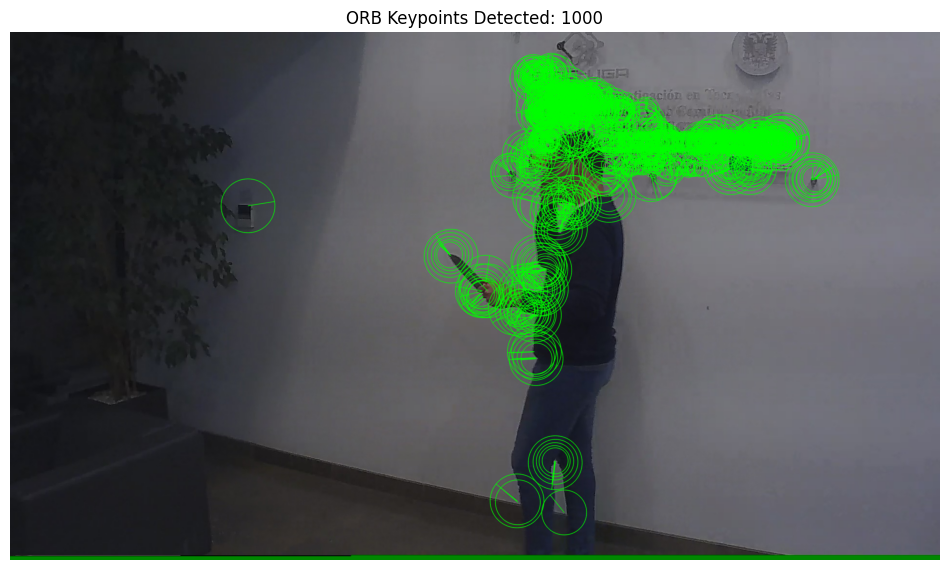

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 1. Load the image
# Using the same path from your dataset
img_path = '/content/dataset_local/dataset/test/danger/ABbframe00154.jpg'
image = cv2.imread(img_path)

# Convert to RGB for Matplotlib display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 2. Convert to grayscale
# Most keypoint detectors operate on single-channel images
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 3. Initialize the ORB detector
# nfeatures=500 is the default; you can increase this to find more points
orb = cv2.ORB_create(nfeatures=1000)

# 4. Detect keypoints and compute descriptors
# Keypoints: Locations (x,y) of interest
# Descriptors: Numerical "fingerprints" of the area around the keypoint
keypoints, descriptors = orb.detectAndCompute(gray, None)

# 5. Draw keypoints on the image
# cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS draws circles indicating
# the size and orientation of the keypoint.
output_image = cv2.drawKeypoints(
    image_rgb,
    keypoints,
    None,
    color=(0, 255, 0),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# 6. Display using matplotlib
plt.figure(figsize=(12, 8))
plt.imshow(output_image)
plt.title(f'ORB Keypoints Detected: {len(keypoints)}')
plt.axis('off')
plt.show()

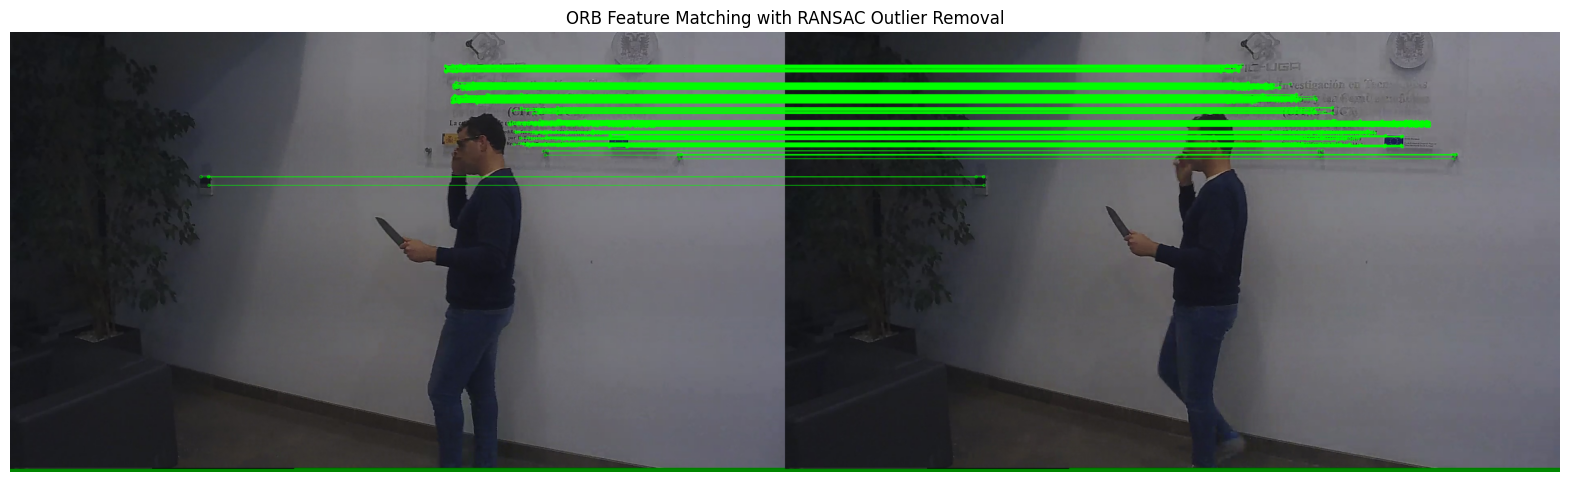

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load two images
# (Using two different images from your danger folder)
img1_path = '/content/dataset_local/dataset/test/danger/ABbframe00154.jpg'
img2_path = '/content/dataset_local/dataset/test/danger/ABbframe00160.jpg'

img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)

# Convert to Grayscale for detection
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# 2. & 3. Initialize ORB and Compute Keypoints/Descriptors
orb = cv2.ORB_create(nfeatures=2000)
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

# 4. Match descriptors using BFMatcher
# ORB uses binary descriptors, so we use NORM_HAMMING
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

# Sort matches by distance (best matches first)
matches = sorted(matches, key=lambda x: x.distance)

# 5. Compute Homography using RANSAC
if len(matches) > 10:
    # Extract locations of matched keypoints
    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    # Find the perspective transformation matrix
    # M is the matrix, mask identifies the "inliers" (the good matches)
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    matchesMask = mask.flatten().tolist()
else:
    print("Not enough matches found!")
    matchesMask = None

# 6. Draw matching keypoints
# We use matchesMask to only draw the "inliers" found by RANSAC
draw_params = dict(matchColor=(0, 255, 0), # draw matches in green
                   singlePointColor=None,
                   matchesMask=matchesMask, # draw only inliers
                   flags=2)

result_img = cv2.drawMatches(img1, kp1, img2, kp2, matches, None, **draw_params)

# Display the result
plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.title('ORB Feature Matching with RANSAC Outlier Removal')
plt.axis('off')
plt.show()

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 1. Load the video
# Replace 'your_video.mp4' with the path to a video file in your Drive or local storage
video_path = '/content/dataset_local/dataset/sample_video.mp4'
cap = cv2.VideoCapture(video_path)

# 2. Initialize the MOG2 Background Subtractor
# detectShadows=True will mark shadows in gray (usually value 127)
fgbg = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=16, detectShadows=True)

# We will grab a few frames to show the progression of the mask
frames_to_show = []
frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret or frame_count > 100: # Stop after 100 frames for this example
        break

    # 3. Apply the background subtractor to get the mask
    # The mask is a binary image: White = Motion, Gray = Shadow, Black = Background
    fgmask = fgbg.apply(frame)

    # Save specific frames (e.g., frame 1, 50, and 100) to visualize the result
    if frame_count in [1, 50, 100]:
        # Convert original frame to RGB for plotting
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames_to_show.append((frame_rgb, fgmask))

    frame_count += 1

cap.release()

# 4. Display the results using Matplotlib
fig, axes = plt.subplots(len(frames_to_show), 2, figsize=(15, 10))
for i, (orig, mask) in enumerate(frames_to_show):
    axes[i, 0].imshow(orig)
    axes[i, 0].set_title(f"Original Frame {i*50}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title(f"MOG2 Foreground Mask")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1500x1000 with 0 Axes>

In [ ]:
r